# Title
Description

In [ ]:
# Imports
import typing
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests


# Task 1
Description

---- Summary ----
Mean:      7.90°C
Median:    8.40°C
Min:     -15.50°C
Max:      23.70°C


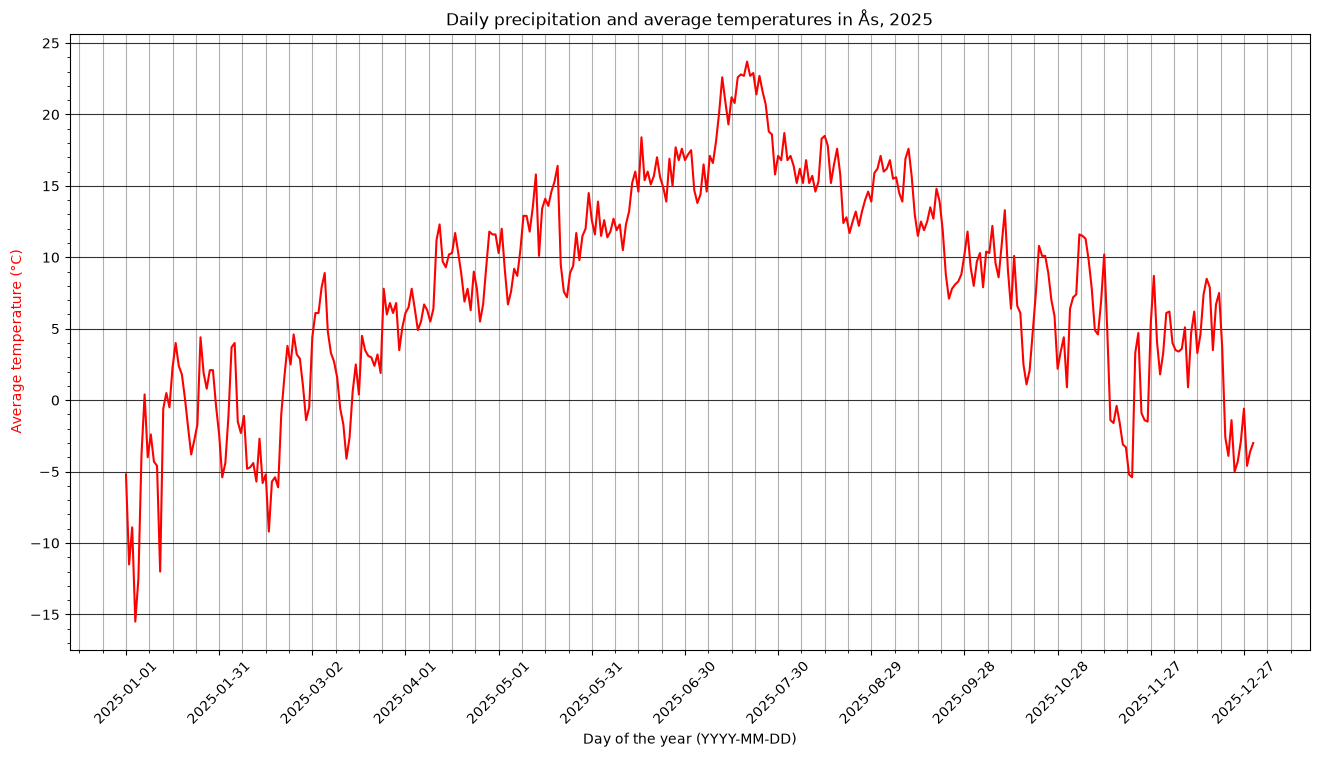

In [ ]:
# Impoert data
endpoint = 'https://frost.met.no/observations/v0.jsonld'
frost_id = open('../frost_id.txt').read().removeprefix("client ID: ")
parameters = {
 'sources': 'SN17850',
 'elements': 'mean(air_temperature P1D)',
 'referencetime': '2025-01-01/2025-12-31',
}
frost_response = requests.get(endpoint, parameters, auth=(frost_id, ""))
assert frost_response.status_code == 200

# Turn the data into a dataframe
frost_payload = frost_response.json()
temp_data = [{'Time': pd.to_datetime(entry['referenceTime']),
              'T_avg': entry['observations'][0]['value']}
              for entry in frost_payload['data']]
wthr_data_df = pd.DataFrame(temp_data)

# Summary statistics
print("---- Summary ----")
print(f"{'Mean:':<7} {wthr_data_df["T_avg"].mean():>7.2f}°C")
print(f"{'Median:':<7} {wthr_data_df["T_avg"].median():>7.2f}°C")
print(f"{'Min:':<7} {wthr_data_df["T_avg"].min():>7.2f}°C")
print(f"{'Max:':<7} {wthr_data_df["T_avg"].max():>7.2f}°C")

# Plotting
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(wthr_data_df['Time'], wthr_data_df['T_avg'], color="r")
ax.set_xticks(pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')[::30])
ax.set_xlabel("Day of the year (YYYY-MM-DD)")
ax.tick_params(axis='x', labelrotation=45)
ax.set_ylabel("Average temperature (°C)", color="r")
ax.grid(True, axis="x", which="both")
ax.grid(True, axis="y", which="major", color="black", alpha=0.8)
ax.minorticks_on()

plt.title("Daily precipitation and average temperatures in Ås, 2025")
plt.show()


# Task 2
Description

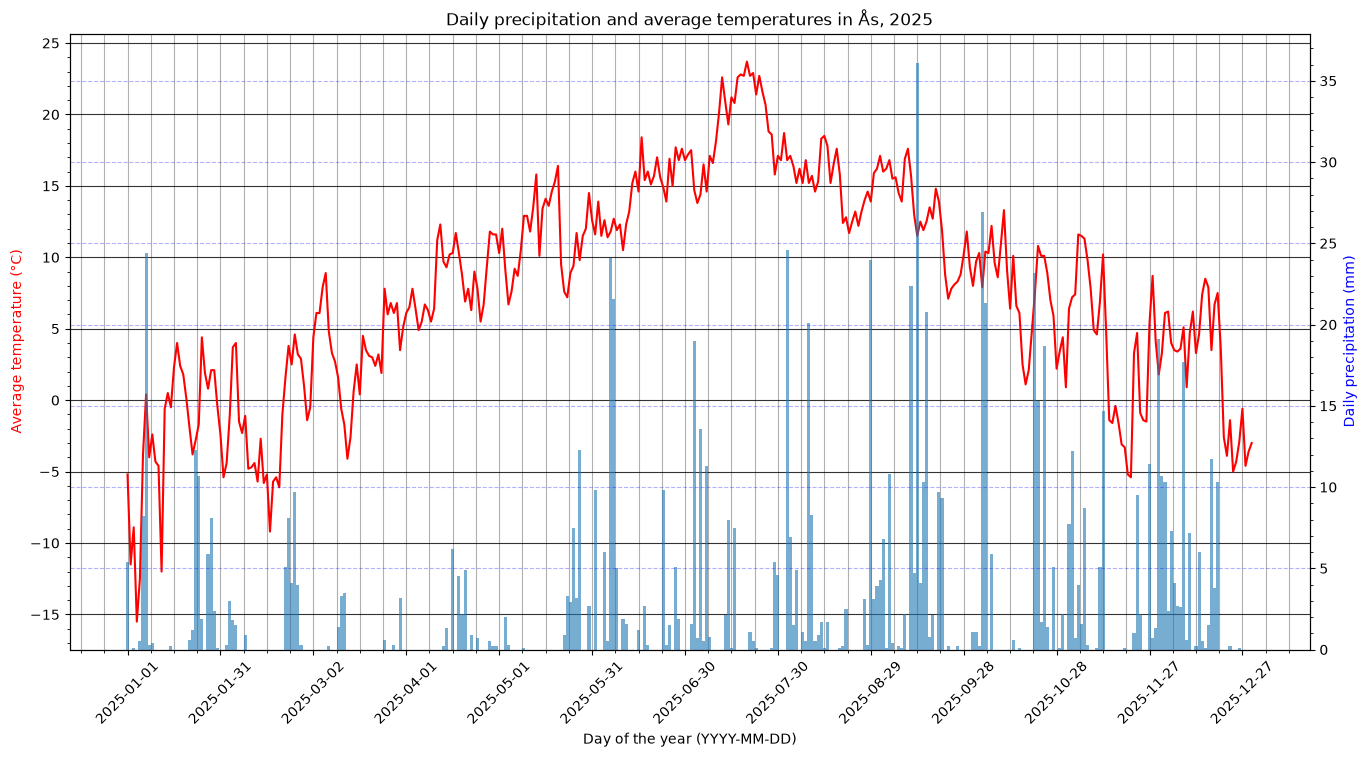

In [ ]:
# Impoert new variable
parameters = {
 'sources': 'SN17850',
 'elements': 'sum(precipitation_amount P1D)',
 'referencetime': '2025-01-01/2025-12-31',
}
frost_response = requests.get(endpoint, parameters, auth=(frost_id, ""))
assert frost_response.status_code == 200

# Add data to the dataframe
frost_payload = frost_response.json()
wthr_data_df["Precip_sum"] = [entry['observations'][0]['value']
                              for entry in frost_payload['data']]

# Plotting
fig, ax1 = plt.subplots(figsize=(16, 8))

ax1.plot(wthr_data_df['Time'], wthr_data_df['T_avg'], color="r")
ax1.set_xticks(pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')[::30])
ax1.set_xlabel("Day of the year (YYYY-MM-DD)")
ax1.tick_params(axis='x', labelrotation=45)
ax1.set_ylabel("Average temperature (°C)", color="r")
ax1.grid(True, axis="x", which="both")
ax1.grid(True, axis="y", which="major", color="black", alpha=0.8)
ax1.minorticks_on()

ax2 = ax1.twinx()
ax2.bar(wthr_data_df['Time'], wthr_data_df['Precip_sum'], width=1, alpha=0.6)
ax2.set_ylabel("Daily precipitation (mm)", color="b")
ax2.grid(True, axis="y", which="major", color="b", linestyle="--", alpha=0.3)
ax2.minorticks_on()

plt.title("Daily precipitation and average temperatures in Ås, 2025")
plt.show()

# Task 3
Description

In [ ]:
# Impoert new variable
parameters = {
 'sources': 'SN17850',
 'elements': 'mean(air_temperature P1D)',
 'referencetime': '1925-01-01/1925-12-31',
}
frost_response = requests.get(endpoint, parameters, auth=(frost_id, ""))
assert frost_response.status_code == 200

# Add data to the dataframe
frost_payload = frost_response.json()
wthr_data_df["T_avg_100y"] = [entry['observations'][0]['value']
                              for entry in frost_payload['data']]

# Summary statistics


# Plotting



# Task 4
Description

In [ ]:
def station_extractor(place: str) -> str:
    """A function for extracting station ID from Frost API, as a string"""
    endpoint = 'https://frost.met.no/sources/v0.jsonld'
    frost_id = open('../frost_id.txt').read().removeprefix("client ID: ")
    parameters = {
        'name': place,
        'types': 'SensorSystem'
    }
    frost_response = requests.get(endpoint, parameters, auth=(frost_id, ""))
    assert frost_response.status_code == 200

    # Turn the data into a dataframe
    frost_payload = frost_response.json()
    return frost_payload['data'][0]['id']


def data_extractor(station_id: str, year: int) -> pd.DataFrame:
    """A function for extracting data from Frost API, as a dataframe"""
    endpoint = 'https://frost.met.no/observations/v0.jsonld'
    frost_id = open('../frost_id.txt').read().removeprefix("client ID: ")
    parameters = {
    'sources': station_id,                       # Ås: SN17850
    'elements': 'max(air_temperature P1D)',
    'referencetime': f'{year}-01-01/{year}-12-31',
    }
    frost_response = requests.get(endpoint, parameters, auth=(frost_id, ""))
    assert frost_response.status_code == 200

    # Turn the data into a dataframe
    frost_payload = frost_response.json()
    temp_data = [{'Time': pd.to_datetime(entry['referenceTime']),
                'T_max': entry['observations'][0]['value']}
                for entry in frost_payload['data']]
    return pd.DataFrame(temp_data)


def heatwave_counter(place: str, year: int) -> int:
    """
    Counts the number of heatwaves recorded in a year
    and summarizes it in a YAML file
    """
    station_id = station_extractor(place)
    wthr_data = data_extractor(station_id, year)

    heatwave_count = 0
    consecutive = 0
    heatwave_days: list[list[pd.Timestamp]] = []
    warm_days: list[pd.Timestamp] = []
    # Tallies consecutive days with max temperature >= 27°C
    for day, temp in enumerate(wthr_data["T_max"]):

        if temp >= 27:
            consecutive += 1
            warm_days.append(wthr_data["Time"].iloc[day])

        else:
            if len(warm_days) >= 5:
                # Appends the ending day of a heatwave
                heatwave_days[heatwave_count - 1].append(warm_days[-1])
            consecutive = 0
            warm_days[:] = []

        if consecutive == 5:
            heatwave_count += 1
            heatwave_days.append([warm_days[0]])

    # Write the heatwave summary to a YAML file
    with open("heatwave_summary.yml", "w") as file:
        file.write("dates:\n")
        for _, days in enumerate(heatwave_days):
            file.write(f"- {days[0].date()} - {days[-1].date()}\n")
        file.write(f"station_id: {station_id}\n")
        file.write(f"station_name: {place}\n")
        file.write(f"year: {year}")

    return heatwave_count


place = "Ås"
year = 2025
heatwaves = heatwave_counter(place, year)
print(f"Number of heatwaves in {place} during {year}: {heatwaves}")

Number of heatwaves in Ås during 2025: 1


# Task 5
Description